# HyConEx from scratch sur Dry Bean Dataset

Ce notebook:
- charge Dry Bean depuis le dossier `dataset/` a la racine,
- applique un feature engineering dedie,
- entraine HyConEx from scratch,
- affiche les metriques classification + AUROC,
- evalue les contre-factuels, dont un apercu sur 10 samples test.

In [9]:
from __future__ import annotations

import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch

ROOT = Path.cwd().resolve().parent
if str(ROOT) not in sys.path:
    sys.path.append(str(ROOT))

from feature_engineering_dry_bean import prepare_dry_bean_splits
from hyconex_from_scratch import TrainConfig, HyConExTrainer

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (8, 5)
np.set_printoptions(precision=4, suppress=True)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
device

device(type='cuda')

In [10]:
splits = prepare_dry_bean_splits(
    test_size=0.2,
    val_size=0.2,
    random_state=42,
    add_engineered_features=True,
    clip_outliers=True,
)

print('Shapes:')
print('train:', splits.X_train.shape, splits.y_train.shape)
print('val  :', splits.X_val.shape, splits.y_val.shape)
print('test :', splits.X_test.shape, splits.y_test.shape)
print('n_features engineered:', len(splits.feature_names))
print('n_classes:', len(splits.class_names))

pd.Series(splits.y_train).value_counts().sort_index().rename(index={i: c for i, c in enumerate(splits.class_names)})

Shapes:
train: (8710, 24) (8710,)
val  : (2178, 24) (2178,)
test : (2723, 24) (2723,)
n_features engineered: 24
n_classes: 7


BARBUNYA     846
BOMBAY       334
CALI        1043
DERMASON    2269
HOROZ       1234
SEKER       1297
SIRA        1687
Name: count, dtype: int64

In [11]:
cfg = TrainConfig(
    seed=42,
    epochs=100,
    batch_size=64,
    lr=1.2e-3,
    weight_decay=1e-5,
    latent_dim=48,
    hidden_dim=128,
    # On augmente la pression de parcimonie pour des CF plus "minimaux".
    cf_lambda=0.20,
    l1_lambda=0.05,
    l2_lambda=0.01,
)

trainer = HyConExTrainer(config=cfg, device=device)
result = trainer.fit(
    splits.X_train,
    splits.y_train,
    X_val=splits.X_val,
    y_val=splits.y_val,
    verbose=True,
)

test_metrics = trainer.evaluate(splits.X_test, splits.y_test, counterfactuals=True)

print('\nBest val accuracy:', f"{result.best_val_accuracy:.4f}")
print('Test accuracy    :', f"{test_metrics['accuracy']:.4f}")
print('Test AUROC OvR   :', test_metrics.get('auroc_ovr'))
print('CF validity      :', f"{test_metrics['counterfactuals']['validity_cf']:.4f}")
print('CF proximity L1  :', f"{test_metrics['counterfactuals']['proximity_l1_mean']:.4f}")

[Epoch 001/100] loss=0.6935 val_acc=0.9008 best_val_acc=0.9008
[Epoch 002/100] loss=0.2621 val_acc=0.9183 best_val_acc=0.9183
[Epoch 003/100] loss=0.2534 val_acc=0.9302 best_val_acc=0.9302
[Epoch 004/100] loss=0.2430 val_acc=0.8972 best_val_acc=0.9302
[Epoch 005/100] loss=0.2351 val_acc=0.9256 best_val_acc=0.9302
[Epoch 006/100] loss=0.2291 val_acc=0.9316 best_val_acc=0.9316
[Epoch 007/100] loss=0.2411 val_acc=0.9293 best_val_acc=0.9316
[Epoch 008/100] loss=0.2287 val_acc=0.9169 best_val_acc=0.9316
[Epoch 009/100] loss=0.2331 val_acc=0.9151 best_val_acc=0.9316
[Epoch 010/100] loss=0.2186 val_acc=0.9339 best_val_acc=0.9339
[Epoch 011/100] loss=0.2212 val_acc=0.9261 best_val_acc=0.9339
[Epoch 012/100] loss=0.2128 val_acc=0.9215 best_val_acc=0.9339
[Epoch 013/100] loss=0.2147 val_acc=0.9233 best_val_acc=0.9339
[Epoch 014/100] loss=0.2307 val_acc=0.9330 best_val_acc=0.9339
[Epoch 015/100] loss=0.2115 val_acc=0.9206 best_val_acc=0.9339
[Epoch 016/100] loss=0.2047 val_acc=0.9233 best_val_acc

In [12]:
history_df = pd.DataFrame(result.history)
history_df.tail()

,epoch,train_loss,val_accuracy,best_val_accuracy
95,96,0.161643,0.933884,0.938476
96,97,0.163265,0.932966,0.938476
97,98,0.169859,0.930211,0.938476
98,99,0.168821,0.933425,0.938476
99,100,0.166028,0.929752,0.938476


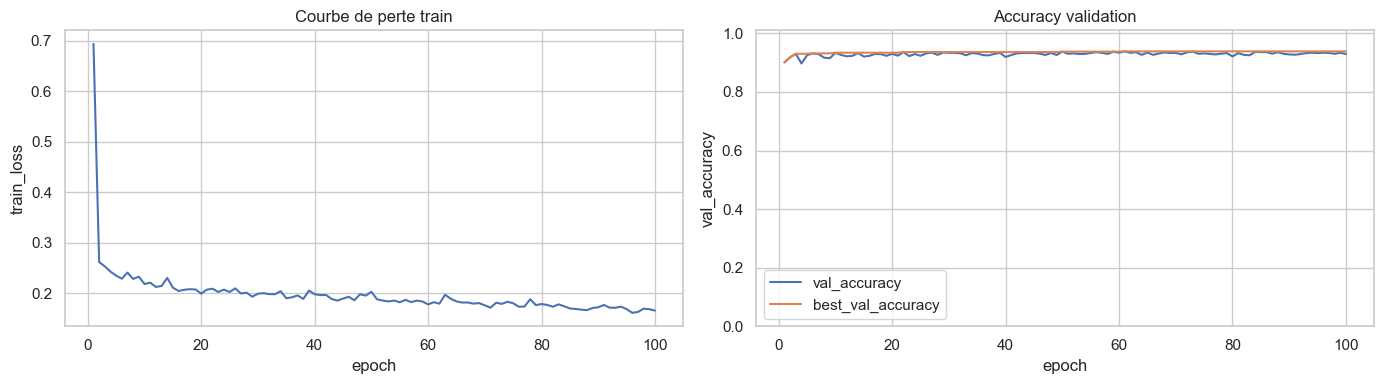

In [13]:
fig, ax = plt.subplots(1, 2, figsize=(14, 4))
sns.lineplot(data=history_df, x='epoch', y='train_loss', ax=ax[0])
ax[0].set_title('Courbe de perte train')

sns.lineplot(data=history_df, x='epoch', y='val_accuracy', ax=ax[1], label='val_accuracy')
sns.lineplot(data=history_df, x='epoch', y='best_val_accuracy', ax=ax[1], label='best_val_accuracy')
ax[1].set_ylim(0.0, 1.01)
ax[1].set_title('Accuracy validation')
plt.tight_layout()
plt.show()

In [14]:
report_df = pd.DataFrame(test_metrics['classification_report']).transpose()
report_df

,precision,recall,f1-score,support
0,0.944664,0.901887,0.922780,265.000000
1,1.000000,1.000000,1.000000,104.000000
2,0.928571,0.957055,0.942598,326.000000
3,0.911602,0.930889,0.921144,709.000000
4,0.957895,0.943005,0.950392,386.000000
5,0.955112,0.943350,0.949195,406.000000
6,0.874286,0.870968,0.872624,527.000000
accuracy,0.925817,0.925817,0.925817,0.925817
macro avg,0.938876,0.935308,0.936962,2723.000000
weighted avg,0.926055,0.925817,0.925821,2723.000000


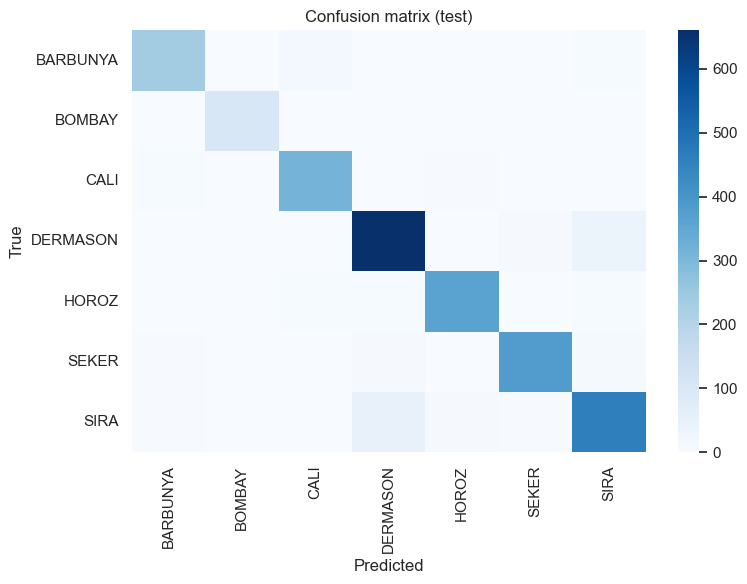

In [15]:
cm = np.array(test_metrics['confusion_matrix'])
cm_df = pd.DataFrame(cm, index=splits.class_names, columns=splits.class_names)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_df, annot=False, cmap='Blues')
plt.title('Confusion matrix (test)')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.tight_layout()
plt.show()

In [16]:
# Evaluation sur 10 samples test (multiclasse) avec filtrage "propre":
# - on ne garde que des exemples correctement classes a l'origine,
# - la cible CF est forcee differente de la prediction originale,
# - on releve le seuil de changement a 1e-2 (plus interpretable),
# - on garde la vue "changement minimal" couvrant 80% du L1.
model = result.model
model.eval()

with torch.no_grad():
    x_test_t = torch.tensor(splits.X_test, dtype=torch.float32, device=result.device)
    y_pred_test = torch.argmax(model(x_test_t), dim=1).cpu().numpy()

correct_pool = np.where(y_pred_test == splits.y_test)[0]
if len(correct_pool) < 10:
    raise ValueError(f"Pas assez d'exemples bien classes pour l'analyse CF: {len(correct_pool)}")

rng = np.random.default_rng(42)
n_examples = 10
idx = rng.choice(correct_pool, size=n_examples, replace=False)

x_sub = torch.tensor(splits.X_test[idx], dtype=torch.float32, device=result.device)
y_sub = torch.tensor(splits.y_test[idx], dtype=torch.long, device=result.device)
y_pred_orig = torch.tensor(y_pred_test[idx], dtype=torch.long, device=result.device)

num_classes = len(splits.class_names)
noise = torch.randint(1, num_classes, size=y_pred_orig.shape, device=result.device)
y_target = (y_pred_orig + noise) % num_classes

with torch.no_grad():
    x_cf = model.generate_counterfactual(x_sub, y_target)
    y_pred_cf = torch.argmax(model(x_cf), dim=1)

x_sub_np = x_sub.cpu().numpy()
x_cf_np = x_cf.cpu().numpy()
y_true_np = y_sub.cpu().numpy()
y_target_np = y_target.cpu().numpy()
y_pred_orig_np = y_pred_orig.cpu().numpy()
y_pred_cf_np = y_pred_cf.cpu().numpy()

change_threshold = 1e-2
rows = []
for i in range(n_examples):
    delta = x_cf_np[i] - x_sub_np[i]
    abs_delta = np.abs(delta)
    changed_idx = np.where(abs_delta > change_threshold)[0]

    if len(changed_idx) > 0:
        top_idx = changed_idx[np.argsort(abs_delta[changed_idx])[::-1][:5]]
        ordered_idx = changed_idx[np.argsort(abs_delta[changed_idx])[::-1]]
        cum = np.cumsum(abs_delta[ordered_idx])
        threshold = 0.80 * abs_delta[changed_idx].sum()
        k_min = int(np.searchsorted(cum, threshold, side='left') + 1)
        minimal_idx = ordered_idx[:k_min]
    else:
        top_idx = np.array([], dtype=int)
        minimal_idx = np.array([], dtype=int)

    rows.append(
        {
            'sample_index_test': int(idx[i]),
            'y_true': splits.class_names[int(y_true_np[i])],
            'y_pred_orig': splits.class_names[int(y_pred_orig_np[i])],
            'target_cf': splits.class_names[int(y_target_np[i])],
            'y_pred_cf': splits.class_names[int(y_pred_cf_np[i])],
            'valid_cf': bool(y_pred_cf_np[i] == y_target_np[i]),
            'l1_distance': float(abs_delta.sum()),
            'changed_features_count': int(len(changed_idx)),
            'minimal_changes_count_80pct_l1': int(len(minimal_idx)),
            'minimal_changed_features_80pct_l1': [splits.feature_names[j] for j in minimal_idx],
            'top_changed_features': [splits.feature_names[j] for j in top_idx],
        }
    )

cf_df = pd.DataFrame(rows)
cf_df

,sample_index_test,y_true,y_pred_orig,target_cf,y_pred_cf,valid_cf,l1_distance,changed_features_count,minimal_changes_count_80pct_l1,minimal_changed_features_80pct_l1,top_changed_features
0,235,CALI,CALI,BOMBAY,BOMBAY,True,1.942671,14,4,"[MajorAxisLength, Major_over_Minor, ShapeFacto...","[MajorAxisLength, Major_over_Minor, ShapeFacto..."
1,2101,SEKER,SEKER,HOROZ,HOROZ,True,2.671099,19,6,"[AspectRation, MajorAxisLength, ShapeFactor4, ...","[AspectRation, MajorAxisLength, ShapeFactor4, ..."
2,243,BARBUNYA,BARBUNYA,DERMASON,DERMASON,True,2.830205,19,7,"[log_Perimeter, log_Area, MajorAxisLength, Per...","[log_Perimeter, log_Area, MajorAxisLength, Per..."
3,1780,CALI,CALI,SEKER,SEKER,True,1.693689,14,5,"[Eccentricity, MajorAxisLength, EquivDiameter,...","[Eccentricity, MajorAxisLength, EquivDiameter,..."
4,1201,DERMASON,DERMASON,HOROZ,HOROZ,True,2.118139,19,8,"[AspectRation, MajorAxisLength, ShapeFactor4, ...","[AspectRation, MajorAxisLength, ShapeFactor4, ..."
5,1187,SIRA,SIRA,HOROZ,HOROZ,True,1.728993,16,7,"[AspectRation, MajorAxisLength, ShapeFactor4, ...","[AspectRation, MajorAxisLength, ShapeFactor4, ..."
6,1899,BARBUNYA,BARBUNYA,HOROZ,HOROZ,True,6.132955,24,11,"[AspectRation, ShapeFactor4, log_Area, Perimet...","[AspectRation, ShapeFactor4, log_Area, Perimet..."
7,258,HOROZ,HOROZ,BOMBAY,BOMBAY,True,2.231955,14,4,"[MajorAxisLength, Major_over_Minor, ShapeFacto...","[MajorAxisLength, Major_over_Minor, ShapeFacto..."
8,562,DERMASON,DERMASON,BOMBAY,BOMBAY,True,2.055290,17,4,"[MajorAxisLength, Major_over_Minor, ShapeFacto...","[MajorAxisLength, Major_over_Minor, ShapeFacto..."
9,2332,CALI,CALI,SIRA,SIRA,True,2.488029,19,7,"[MajorAxisLength, Perimeter, EquivDiameter, lo...","[MajorAxisLength, Perimeter, EquivDiameter, lo..."


## Lecture rapide des resultats

- **Accuracy test** : performance de classification globale.
- **AUROC** : qualite de separation probabiliste.
- **CF validity** : part des contre-factuels qui atteignent la classe cible.
- **L1 distance** : ampleur moyenne du changement requis.